In [89]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error,r2_score
from xgboost.callback import EarlyStopping
import matplotlib.pyplot as plt
%matplotlib inline

In [15]:
from sklearn.datasets import fetch_california_housing
data=fetch_california_housing()
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [16]:
X=pd.DataFrame(data.data,columns=data.feature_names)
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [18]:
y=pd.DataFrame(data.target)
y[:5]

,0
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [20]:
X.shape

(20640, 8)

In [23]:
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [24]:
X.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [27]:
y.isnull().sum()

0    0
dtype: int64

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [21]:
X_train.shape

(16512, 8)

In [22]:
X_test.shape

(4128, 8)

In [29]:
#Model Building

In [32]:
model=XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    random_state=42
)

In [46]:
model.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [47]:
y_pred=model.predict(X_test)

In [48]:
y_pred[:5]

array([0.44671366, 1.0241188 , 3.9819834 , 2.406479  , 2.1079211 ],
      dtype=float32)

In [51]:
X_test.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93


In [53]:
mse = mean_squared_error(y_test, y_pred)
mse

0.2917180359363556

In [56]:
rmse = np.square(mse)
rmse

np.float64(0.08509941249056485)

In [59]:
r2_error=r2_score(y_test,y_pred)
r2_error

0.7773839831352234

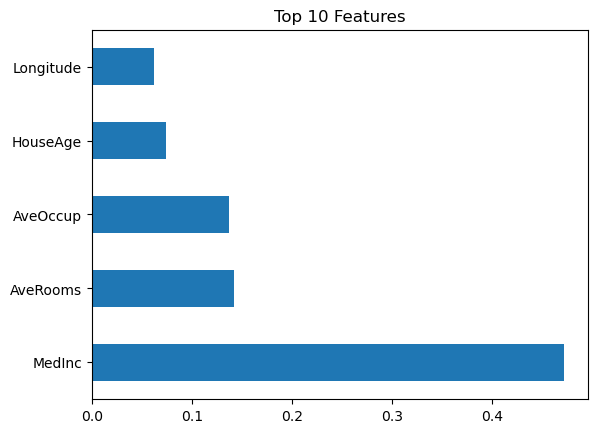

In [71]:
features=pd.Series(model.feature_importances_,index=X.columns)
features.sort_values(ascending=False).head(5).plot(kind='barh')
plt.title('Top 10 Features')
plt.show()

In [75]:
param_grid = {
    'learning_rate':[0.01, 0.05, 0.1, 0.5],
    'n_estimators': [50, 100, 150, 200, 250, 300],
    'max_depth': [3,4,5],
    'subsample': [0.6,0.7,0.8],
    'colsample_bytree': [0.6,0.7,0.8]  
}
grid=GridSearchCV(
    estimator=XGBRegressor(),
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=1
)


In [76]:
grid.fit(X_train,y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.6, 0.7, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [50, 100, ...], ...}"
,scoring,'neg_mean_squared_error'
,n_jobs,1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [80]:
best_model=grid.best_estimator_

In [81]:
y_pred=best_model.predict(X_test)

In [82]:
mse=mean_squared_error(y_test,y_pred)
mse

0.20524519681930542

In [83]:
rmse=np.sqrt(mse)
rmse

np.float64(0.4530399505775461)

In [84]:
r2_square=r2_score(y_test,y_pred)
r2_square

0.84337317943573

In [95]:
def adjusted_r2(r2,X):
    n=X.shape[0] #number of data points
    p=X.shape[1] #number of features
    return 1 - (1-r2)* (n-1)/(n-p-1)

In [97]:
adj_r2=adjusted_r2(r2_square,X_test)
adj_r2

0.84306897585124